# **1. Data Ingestion & Quality Profiling**

### 1.1 Load & Inspect

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('car_prices.csv')
display(df.head())
df.info()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


### 1.2 Understanding the Data Structure

In [22]:
print(df.shape)
print(df.dtypes)

(558837, 16)
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


### 1.3 Missing & Anomaly Detection

make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
condition       11820
odometer           94
color             749
interior          749
mmr                38
sellingprice       12
saledate           12
dtype: int64


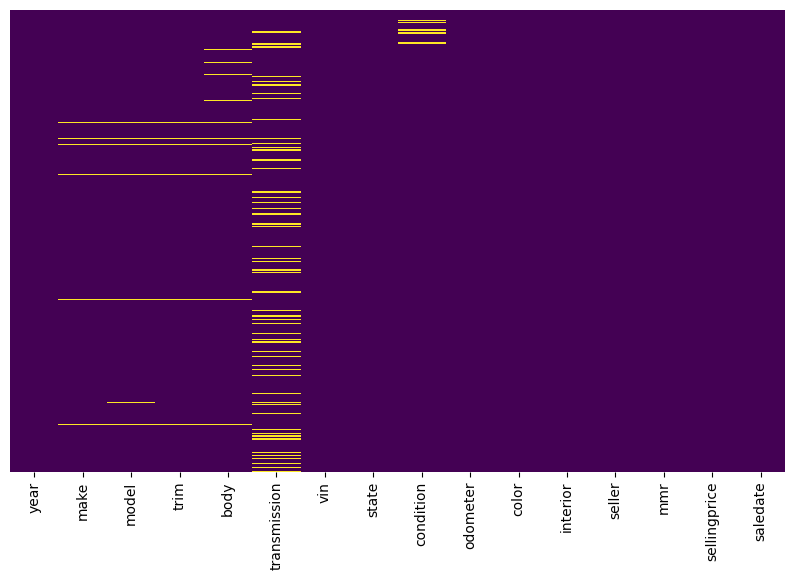

In [23]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.show()

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()

# **2. Data frames Queries:**

### 2.1 Calculate the average, minimum, and maximum car price?

In [24]:
avg_price = df['sellingprice'].mean()
min_price = df['sellingprice'].min()
max_price = df['sellingprice'].max()
print(avg_price,"     ", min_price,"     ", max_price)

13611.326356343621       1.0       230000.0


### 2.2 List all unique colors of cars?

In [25]:
unique_colors = df['color'].unique()
print(unique_colors)

['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime' '4802' '9410' '1167' '2172' '14872' '12655'
 '15719' '6388' '16633' '11034' '2711' '6864' '339' '18384' '9887' '9837'
 '20379' '20627' '721' '6158' '2817' '5705' '18561' '2846' '9562' '5001']


### 2.3 Find the number of unique car brands and car models?

In [26]:
unique_brands = df['make'].nunique()
unique_models = df['model'].nunique()
print(unique_brands,"     ", unique_models)

96       973


### 2.4 Find all car information having selling prices greater than $165000?

In [27]:

expensive_cars = df[df['sellingprice'] > 165000]
display(expensive_cars)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


### 2.5 Find the top 5 most frequently sold car models?

In [28]:
top_5_models = df['model'].value_counts().head(5)
print(top_5_models)

model
Altima    29748
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64


### 2.6 What is the average selling price of cars by brand (make)?

In [29]:
avg_price_by_brand = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)
print(avg_price_by_brand)

make
Rolls-Royce    153488.235294
Ferrari        127210.526316
Lamborghini    112625.000000
Bentley         74367.672414
airstream       71000.000000
                   ...      
dodge tk          550.000000
Geo               528.947368
dot               500.000000
ford truck        483.333333
Daewoo            400.000000
Name: sellingprice, Length: 96, dtype: float64


### 2.7 What is the minimum selling price of cars for each interior?

In [30]:
min_price_by_interior = df.groupby('interior')['sellingprice'].min()
print(min_price_by_interior)

interior
beige         100.0
black           1.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            1.0
green         100.0
off-white     900.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
—             150.0
Name: sellingprice, dtype: float64


### 2.8 Find highest odometer reading per year from highest to lowest order?

In [31]:
max_odo_per_year = df.groupby('year')['odometer'].max().sort_values(ascending=False)
print(max_odo_per_year)

year
1997    999999.0
1996    999999.0
2014    999999.0
2013    999999.0
1998    999999.0
1999    999999.0
1993    999999.0
2010    999999.0
2009    999999.0
2012    999999.0
2008    999999.0
2007    999999.0
2005    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2011    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64


### 2.9 Create a new column for car age (assuming the current year is 2025)

In [32]:
df['car_age'] = 2025 - df['year']

### 2.10 Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000?condition_odo_filter = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]

In [33]:
print(len(condition_odo_filter))

746


### 2.11 Which state consistently has higher car prices for newer cars(year>2013)?

In [34]:
newer_cars = df[df['year'] > 2013]
state_prices = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)
print(state_prices.index[0])

oh


### 2.12 For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)?

In [35]:
top_20_threshold = df['condition'].quantile(0.80)
excellent_condition_cars = df[df['condition'] >= top_20_threshold]
value_for_money_makes = excellent_condition_cars.groupby('make')['sellingprice'].mean().sort_values(ascending=True).head(5)
print(value_for_money_makes)

make
Isuzu         1125.000000
Oldsmobile    1910.000000
honda         4233.333333
Saturn        5700.406504
subaru        6200.000000
Name: sellingprice, dtype: float64


# **3. Data Visualization and Insights**

### 3.1 Show the correlation of all the features(columns) having numerical values

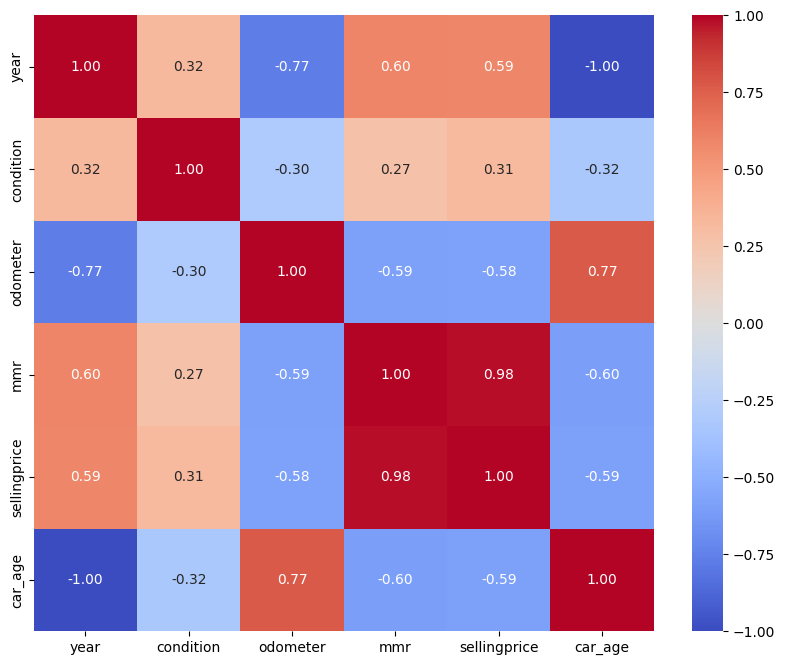

In [36]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

### 3.2 Plot a graph to show the average selling price by year

/tmp/ipykernel_3054/3492145822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_year, x='year', y='sellingprice', palette='viridis')


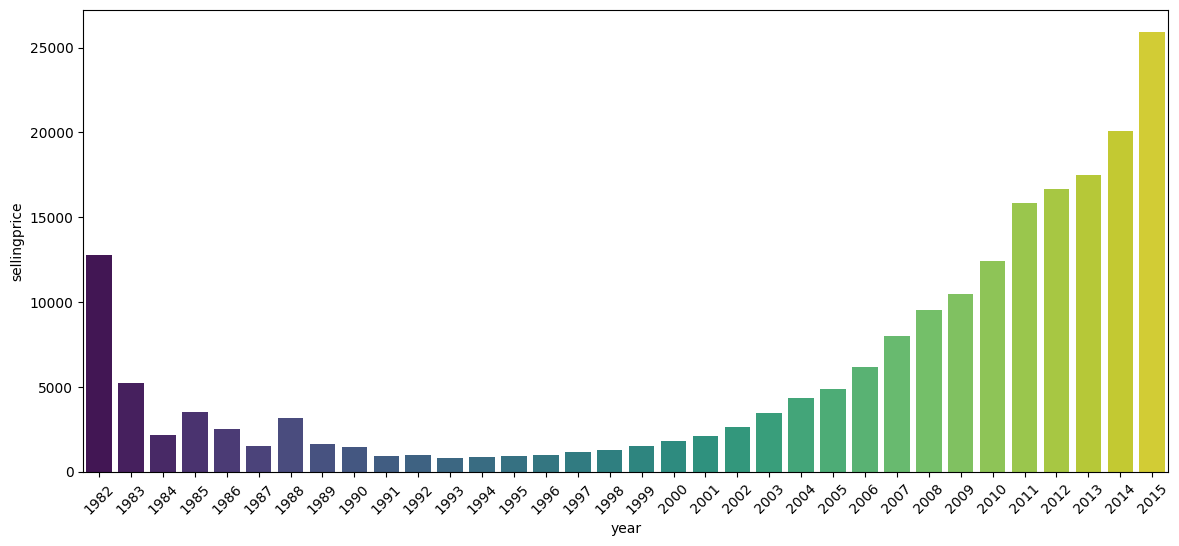

In [37]:
avg_price_year = df.groupby('year')['sellingprice'].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.barplot(data=avg_price_year, x='year', y='sellingprice', palette='viridis')
plt.xticks(rotation=45)
plt.show()

### 3.3 Plot a graph to show average selling price by odometer

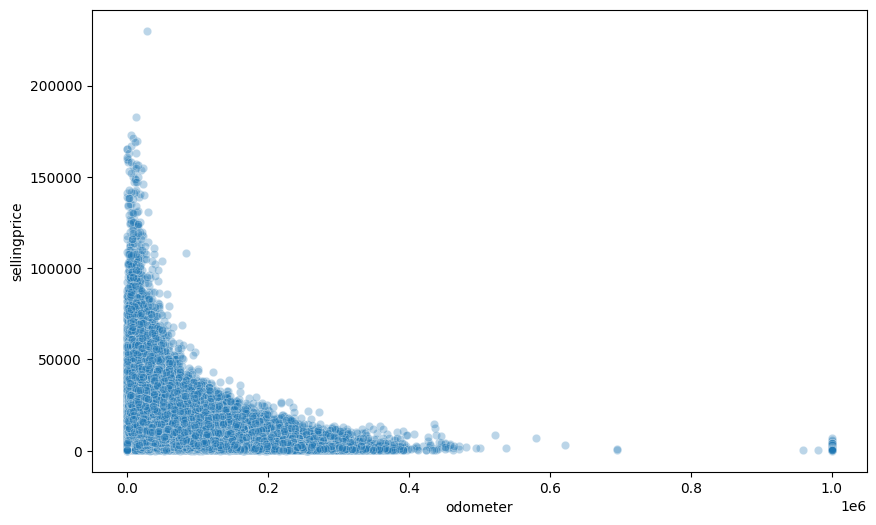

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='odometer', y='sellingprice', alpha=0.3)
plt.show()

### 3.4 Plot a graph to show the number of cars sold in each state

/tmp/ipykernel_3054/4236108891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='magma')


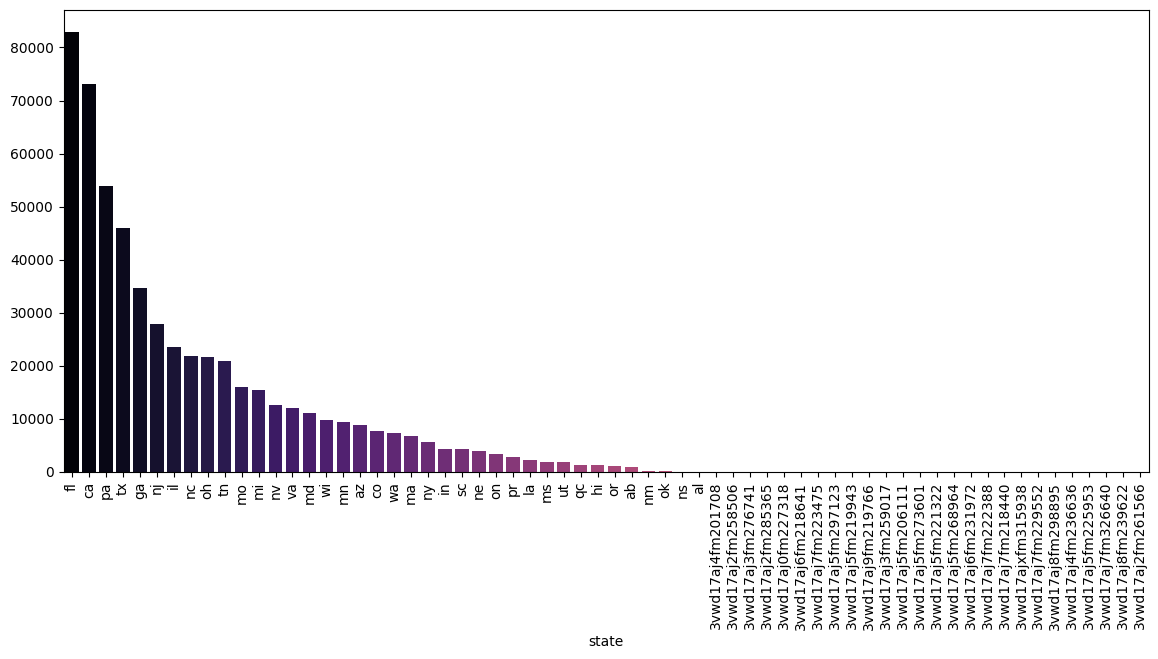

['fl', 'ca', 'pa']


In [39]:
plt.figure(figsize=(14, 6))
state_counts = df['state'].value_counts()
sns.barplot(x=state_counts.index, y=state_counts.values, palette='magma')
plt.xticks(rotation=90)
plt.show()
print(state_counts.index[:3].tolist())

### 3.5 Plot a bar graph of average selling price by condition score ranges of size 5

/tmp/ipykernel_3054/3050956112.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_cond, x='condition_range_5', y='sellingprice', palette='mako')


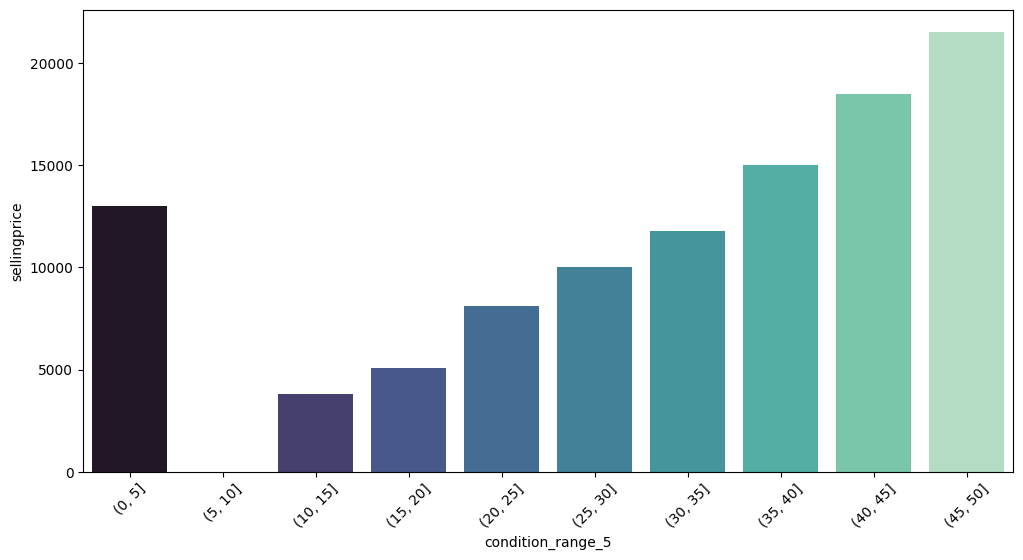

In [40]:
max_condition = int(df['condition'].max())
bins_5 = range(0, max_condition + 6, 5)
df['condition_range_5'] = pd.cut(df['condition'], bins=bins_5)

plt.figure(figsize=(12, 6))
avg_price_cond = df.groupby('condition_range_5', observed=False)['sellingprice'].mean().reset_index()
sns.barplot(data=avg_price_cond, x='condition_range_5', y='sellingprice', palette='mako')
plt.xticks(rotation=45)
plt.show()

### 3.6 Plot a bar graph of no. of cars sold by condition ranges of size 10

/tmp/ipykernel_3054/1004582951.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='condition_range_10', palette='rocket')


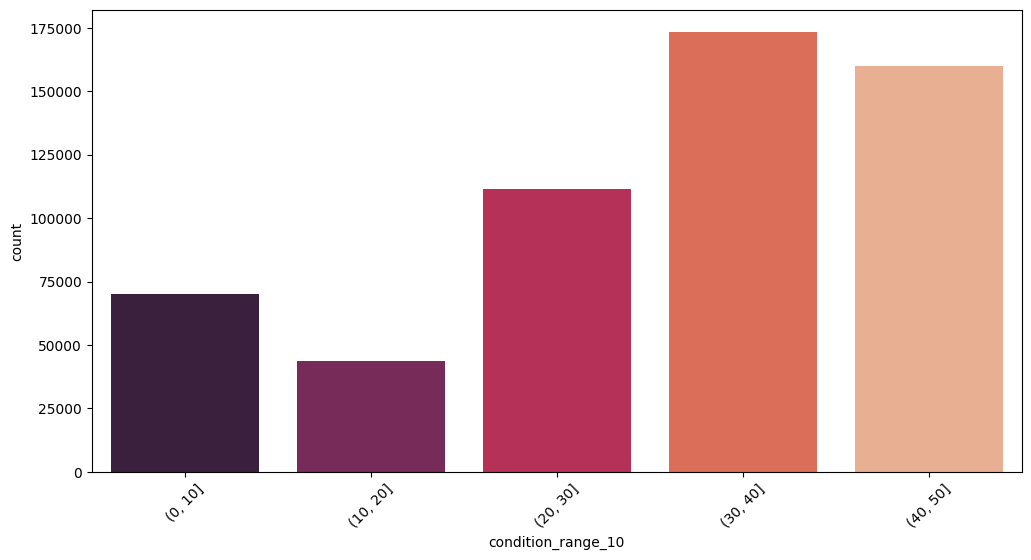

In [41]:
bins_10 = range(0, max_condition + 11, 10)
df['condition_range_10'] = pd.cut(df['condition'], bins=bins_10)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='condition_range_10', palette='rocket')
plt.xticks(rotation=45)
plt.show()

### 3.7 Plot a box plot to show the distribution of car selling prices grouped by color

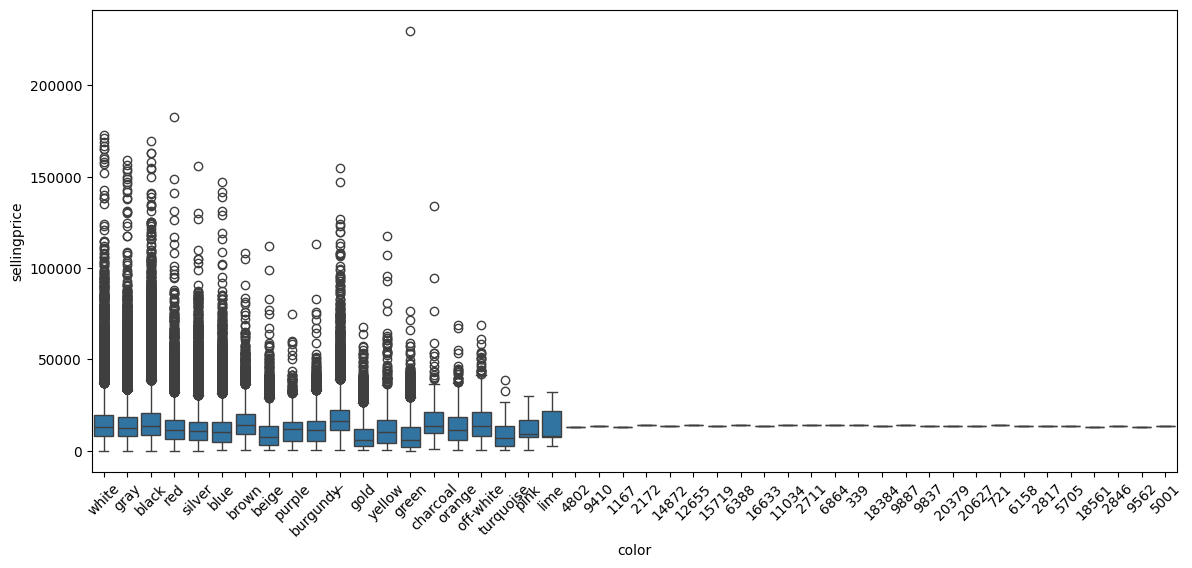

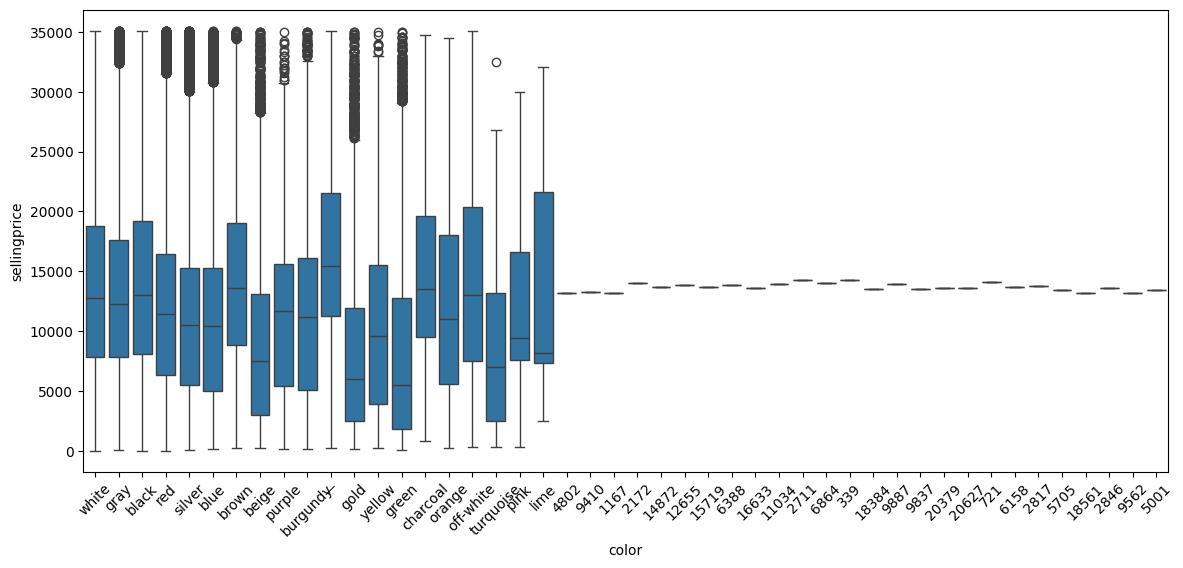

In [42]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='color', y='sellingprice')
plt.xticks(rotation=45)
plt.show()

Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['sellingprice'] >= lower_bound) & (df['sellingprice'] <= upper_bound)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_no_outliers, x='color', y='sellingprice')
plt.xticks(rotation=45)
plt.show()